# S07 Extra 01 — Self-Organizing Map (Kohonen SOM)

Этот ноутбук **опциональный**: он расширяет тему семинара S07 и соответствует блоку про карты Кохонена из лекции.

## Как использовать
- Можно читать/запускать как самостоятельный материал после S07.
- В домашнее задание HW07 **не входит**.

## Что внутри
- Интуиция SOM: поиск BMU (нейрона-победителя), обновление весов, “соседство” на карте.
- Пример на изображении (квантование/сжатие цветов) как наглядная демонстрация.

## Требования
- numpy, matplotlib, tqdm, scikit-learn (для `load_sample_image`), pillow (PIL).


## Самоорганизующиеся карты Кохонена


Идея метода была предложена финским ученым Т. Кохоненом в 1984 году.
Нейронные сети Кохонена - типичный пример нейросетевой архитектуры, обучающейся без учителя.

В основе идеи сети Кохонена лежит аналогия со свойствами человеческого мозга. Кора головного мозга человека представляет собой плоский лист и свернута складками. Таким образом, можно сказать, что она обладает определенными топологическими свойствами (участки, ответственные за близкие части тела, примыкают друг к другу, и все изображение человеческого тела отображается на эту двумерную поверхность).

Уникальность метода самоорганизующихся карт состоит в преобразовании n-мерного пространства в двумерное (обычно). Самоорганизующиеся карты Кохонена широко применяются для прогнозирования, классификации, кластеризации, поиска закономерностей в больших массивах данных, выявления наборов независимых признаков, уменьшения размерности данных с минимальной потерей информации и визуализации.

![img](https://intuit.ru/EDI/21_01_20_1/1579558792-21349/tutorial/25/objects/12/files/12_1.png)

Сеть Кохонена имеет всего два слоя: входной и выходной. Количество входных переменных нейронной сети равно числу признаков, характеризующих данные, на основе которых происходит отнесение данных к одному из кластеров. Количество выходных нейронов равно количеству кластеров. Нейроны выходного слоя располагаются в узлах двумерной сетки с прямоугольными или шестиугольными ячейками. Применение именно двумерных сеток наиболее распространено из-за визуализации, бывают сетки и другой размерности.

![img](https://loginom.ru/sites/default/files/blogpost-files/taxonomy_0.svg)

Обучение при этом заключается не в минимизации ошибки учителя, которого нет, а в подстройке параметров нейронной сети для наибольшего совпадения нейронов с входными данными. Значение "веса" в данном случае отличается от привычного. Здесь веса это координаты нейрона в пространстве признаков.




Сеть Кохонена обучается по итерациям. Пусть t – номер итерации.
1. Инициализировать веса.

 Первый способ инициализации - выбрать для каждого весового вектора некоторый элемент из набора входных значений и установить значения весовых компонент равными компонентам выбранного вектора. Плюс такого подхода в том, что требуется меньше итераций на этапе обучения.

 Второй способ - случайные значения. Плюсом данного подхода является простота, но обучение может быть долгим.

 Третий способ - равномерно расставить нейроны в пространстве входов.
2. Выбрать случайный вектор x(t) из набора входных значений.
3. Найти расстояния до векторов весов всех нейронов карты и определить наиболее похожий по метрике нейрон. Этот нейрон объявляется победителем. Если существует несколько одинаково близких нейронов, то победитель выбирается случайным образом.  
4. Определить функцию соседства нейронов и изменить веса нейронов в карте.

 Функция соседства h(t) — функция, постепенно изменяющая векторы весов сначала у большего количества узлов и сильнее, потом у меньшего и слабее. Обычно используют Гауссову функцию.

 Векторы весов изменяются по формуле:

 $𝑚_𝑖(𝑡)=𝑚_𝑖(𝑡−1)+ℎ(𝑡)(𝑥(𝑡)−𝑚_𝑖(𝑡−1))$,

 где $𝑚_𝑖$ - это вектор весов.
Таким образом, все узлы, являющиеся соседями нейрона-победителя, становятся еще ближе к рассматриваемому x(t).
6. Вычислить ошибку карты, например, как среднее арифметическое расстояний между входными данными и векторами весов соответствующих им нейронов-победителей $\frac{1}{N}\sum_{i = 1}^N ||x_i-m_c||$, где N - количество элементов набора входных данных.
7. Проверить критерий остановки. Если он не выполнен, перейти к шагу 2.

 Критерием остановки может быть:
- максимальное количество итераций,
- минимальная точность, равная сумме средних изменений весов в итерации обучения,
- исчерпание всех возможных наборов векторов наблюдаемых данных.

![img](https://algowiki-project.org/algowiki/pool/images/0/0c/InfGraphSOMSecond.png)




В результате работы алгоритма получаем набор карт:
- карта входов нейронов,
- карта выходов нейронов,
- специальные карты.

**Карта входов нейронов.**

Веса нейронов подстраиваются под значения входных переменных и отображают их внутреннюю структуру. Карта раскрашивается в соответствии со значением конкретного веса нейрона. Область определенного цвета означает, что соответствующие ей данные имеют приблизительно одинаковые значения параметров.

**Карта выходов нейронов.**

На карту выходов отображаются кластеры - замкнутые области на карте, которые включают нейроны с одинаковыми значениями выходов. Центр кластера характеризует векторы входных данных, для которых он является нейроном-победителем.

**Специальные карты.**

Это карта кластеров, матрица расстояний, матрица плотности попадания и другие карты, которые характеризуют кластеры, полученные в результате обучения сети Кохонена.

Важно понимать, что все эти карты являются разными раскрасками одних и тех же нейронов. Каждый вектор входных данных имеет одно и то же расположение на всех картах.


При практическом использовании нейронной сети Кохонена новый вектор данных подается на ее вход и относится к одному из существующих кластеров, либо делается вывод о невозможности такого отнесения при большом расстоянии до центра ближайшего кластера.

Основные преимущества алгоритма:

- устойчивость к зашумленным данным,
- быстрое обучение,
- возможность визуализировать многомерные входные данные.

Минусы алгоритма:
- чувствительность к начальным значениям,
- требуется предположить количество кластеров.


In [1]:
#Импортируем библиотеки
import numpy as np
import matplotlib.pyplot as plt

In [9]:
from tqdm.notebook import tqdm
# Функция возвращает индексы g, h нейрона-победителя
def find_BMU(SOM,x):
    distSq = (np.square(SOM - x)).sum(axis=2) # используется евклидово расстояние
    return np.unravel_index(np.argmin(distSq, axis=None), distSq.shape)

# Обновляем веса, когда подается входной вектор train_ex
# learn_rate - скорость обучения сети
# radius_sq - определяет область влияния входного вектора, так как чем дальше нейроны, тем меньше изменяются их веса
# step - число изменяющихся соседей
def update_weights(SOM, train_ex, learn_rate, radius_sq,
                   BMU_coord, step=3):
    g, h = BMU_coord # Параметры нейрона-победителя представляются в виде кортежа
    # Если радиус близок к нулю, то обновляется только нейрон-победитель
    if radius_sq < 1e-3:
        SOM[g,h,:] += learn_rate * (train_ex - SOM[g,h,:])
        return SOM
    # Изменяются нейроны в окрестности нейрона-победителя
    # Здесь функция соседства dist_func зависит от dist_sq - расстояния между нейронами (i,j) и победителем(g,h)
    for i in range(max(0, g-step), min(SOM.shape[0], g+step)):
        for j in range(max(0, h-step), min(SOM.shape[1], h+step)):
            dist_sq = np.square(i - g) + np.square(j - h)
            dist_func = np.exp(-dist_sq / 2 / radius_sq)
            SOM[i,j,:] += learn_rate * dist_func * (train_ex - SOM[i,j,:])
    return SOM

# Процесс обучения карты
# На вход можно подать начальную SOM, либо уже частично тренированную до какого-нибудь этапа
# lr_decay - показатель затухания для скорости обучения, radius_decay - показатель затухания для радиуса
# Значения параметров заданы по умолчанию, их можно менять
def train_SOM(SOM, train_data, learn_rate = .1, radius_sq = 1,
             lr_decay = .1, radius_decay = .1, epochs = 10):
    learn_rate_0 = learn_rate
    radius_0 = radius_sq
    for epoch in tqdm(np.arange(0, epochs)):
        rand.shuffle(train_data.copy())    # Случайным образом изменяет порядок входных данных
        for train_ex in train_data:
            g, h = find_BMU(SOM, train_ex)
            SOM = update_weights(SOM, train_ex,
                                 learn_rate, radius_sq, (g,h))
        # Изменяем скорость обучения и радиус экспоненциально
        learn_rate = learn_rate_0 * np.exp(-epoch * lr_decay)
        radius_sq = radius_0 * np.exp(-epoch * radius_decay)
    return SOM

In [10]:
from sklearn.datasets import load_sample_image
img = load_sample_image("china.jpg")

# Load Image and transform to a 2D numpy array.

from PIL import Image
img=Image.fromarray(img)
img=img.resize([80,60])
img=np.asarray(img)
img =np.array(img, dtype=np.float64) / 255
w, h, d = original_shape = tuple(img.shape)
assert d == 3
train_data = np.reshape(img, (w * h, d))

In [11]:
img[0,0,0]

0.6862745098039216

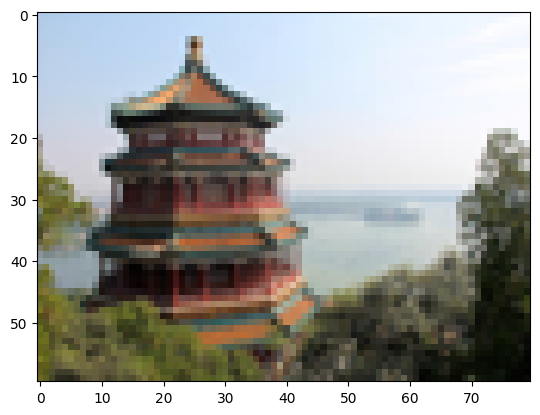

In [12]:
plt.imshow(img)

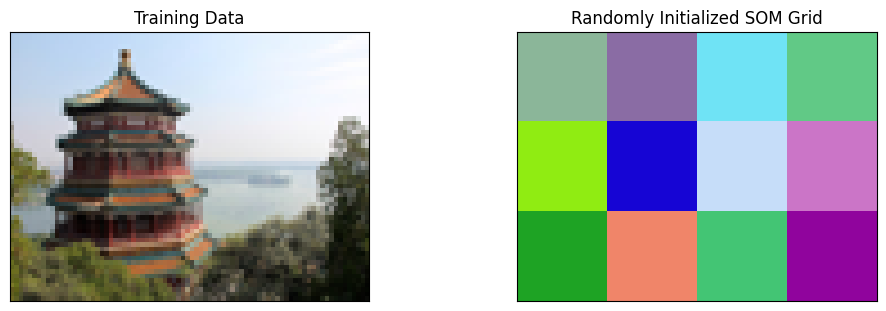

In [15]:
# Задаем размерность решетки
m = 3 # 30
n = 4 # 40
# Задаем объем обучающих данных

rand = np.random.RandomState(0)
# Инициализируем обучающую выборку случайными значениями цветов RGB
#train_data = rand.randint(0, 255, (n_x, 3))
# Инициализируем веса случайными значениями цветов RGB
SOM = rand.rand(m, n, 3)
# Выведем обучающие данные и начальную карту
fig, ax = plt.subplots(
    nrows=1, ncols=2, figsize=(12, 3.5),
    subplot_kw=dict(xticks=[], yticks=[]))
# Для визуализации матрицу 3000*3 превратили в 50*60*3
ax[0].imshow(img)
ax[0].title.set_text('Training Data')
ax[1].imshow(SOM)
ax[1].title.set_text('Randomly Initialized SOM Grid')

Epoch: 1


  0%|          | 0/1 [00:00<?, ?it/s]

Epoch: 4


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 9


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 19


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 49


  0%|          | 0/30 [00:00<?, ?it/s]

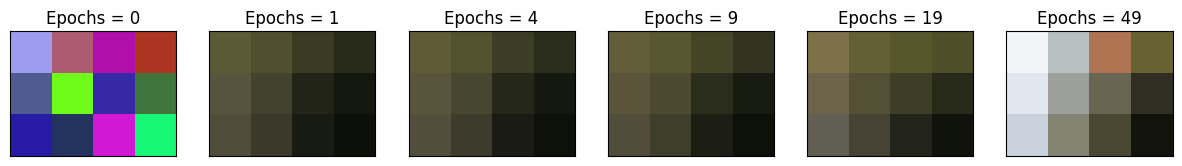

In [16]:
#Выведем прогресс карты для нескольких итераций
ephs=[1, 3, 5, 10, 30] # эпохи обучения, накопительный эффект
n_ephs=len(ephs)
fig, ax = plt.subplots(
    nrows=1, ncols=n_ephs+1, figsize=(15, 3.5),
    subplot_kw=dict(xticks=[], yticks=[]))

total_epochs = 0 # общее число эпох

# Начальный
SOM = rand.rand(m, n, 3) #  инициализация карты
i=0
ax[i].imshow(SOM)
ax[i].title.set_text('Epochs = ' + str(total_epochs))

for epochs, i in zip(ephs, range(1,n_ephs+1)):
    total_epochs += epochs
    print("Epoch:", total_epochs)
    SOM = train_SOM(SOM, train_data, epochs=epochs) # обучение карты
    ax[i].imshow(SOM)
    ax[i].title.set_text('Epochs = ' + str(total_epochs))

## Материалы

https://rubikscode.net/2018/08/20/introduction-to-self-organizing-maps/

https://medium.com/machine-learning-researcher/self-organizing-map-som-c296561e2117

[https://algowiki-project.org](https://algowiki-project.org/ru/%D0%A1%D0%B0%D0%BC%D0%BE%D0%BE%D1%80%D0%B3%D0%B0%D0%BD%D0%B8%D0%B7%D1%83%D1%8E%D1%89%D0%B0%D1%8F%D1%81%D1%8F_%D0%BA%D0%B0%D1%80%D1%82%D0%B0_%D0%9A%D0%BE%D1%85%D0%BE%D0%BD%D0%B5%D0%BD%D0%B0_(%D0%B0%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC_%D0%BA%D0%BB%D0%B0%D1%81%D1%82%D0%B5%D1%80%D0%B8%D0%B7%D0%B0%D1%86%D0%B8%D0%B8))

https://stackabuse.com/self-organizing-maps-theory-and-implementation-in-python-with-numpy/




## Задания

1. Для карты Кохонена поменяйте параметры learn_rate и radius_sq. Посмотрите, как изменение параметров влияет на результат работы алгоритма.

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

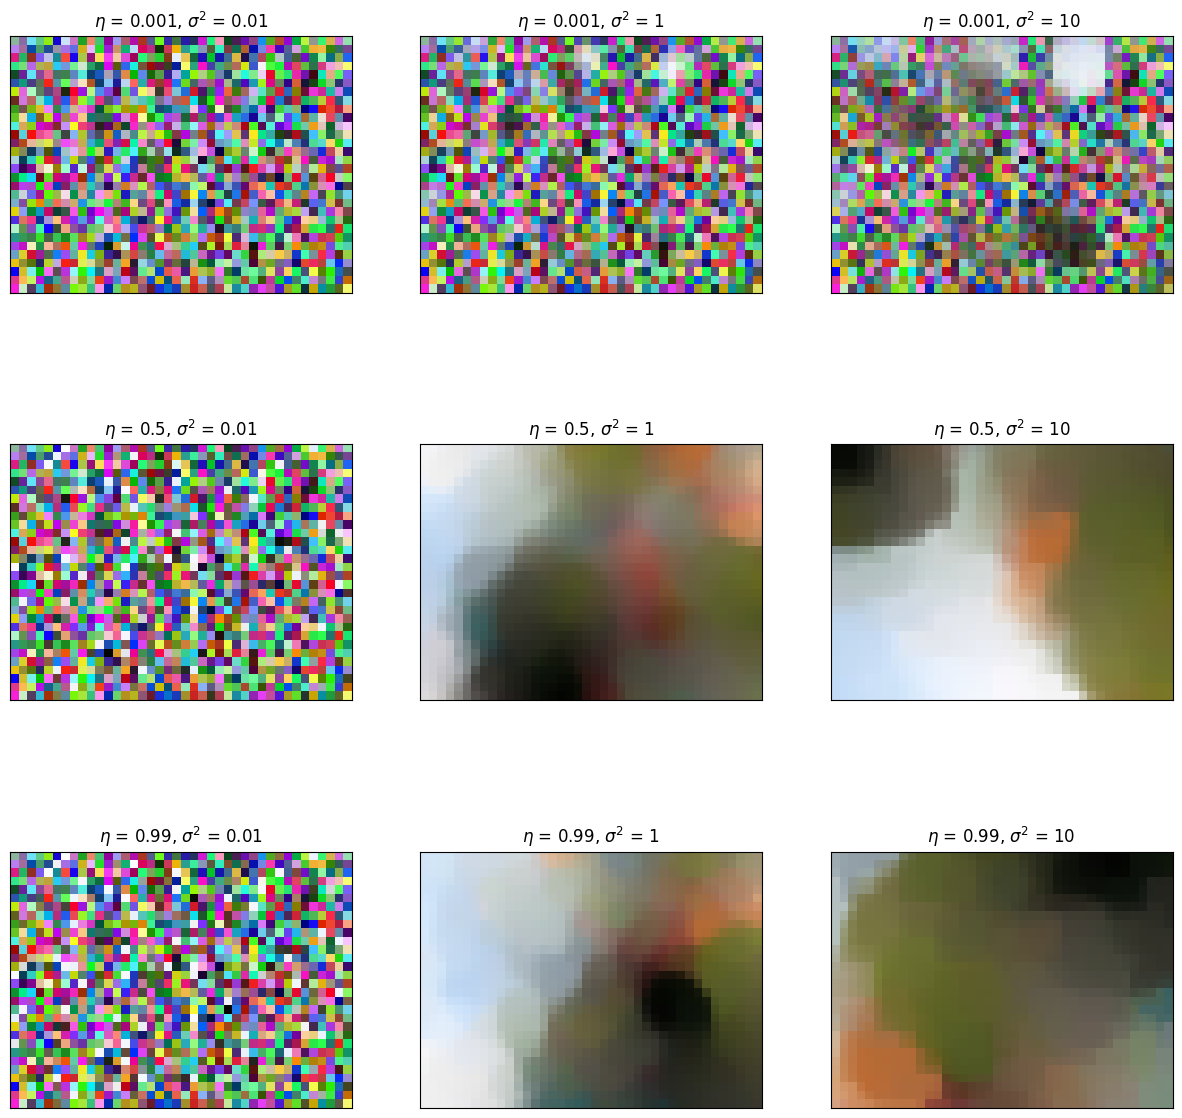

In [17]:
#@title Решение
m = 30
n = 40
# Задаем объем обучающих данных
rand = np.random.RandomState(0)
SOM = rand.rand(m, n, 3)

fig, ax = plt.subplots(
    nrows=3, ncols=3, figsize=(15, 15),
    subplot_kw=dict(xticks=[], yticks=[]))



for learn_rate, i in zip([0.001, 0.5, 0.99], [0, 1, 2]):
    for radius_sq, j in zip([0.01, 1, 10], [0, 1, 2]):
        rand = np.random.RandomState(0)
        SOM = rand.rand(m, n, 3)
        SOM = train_SOM(SOM, train_data, epochs = 5,
                        learn_rate = learn_rate,
                        radius_sq = radius_sq)
        ax[i][j].imshow(SOM)
        ax[i][j].title.set_text('$\eta$ = ' + str(learn_rate) +
                                ', $\sigma^2$ = ' + str(radius_sq))

2. Разберите самостоятельно, как использовать библиотеку minisom, реализующую карты Кохонена. Пример использования можно найти [тут](https://github.com/JustGlowing/minisom/blob/master/examples/BasicUsage.ipynb).

Альтернативой и развитием карт Кохонена являются методы типа Растущего нейронного газа, в которых придуманы способы настройки самой карты.
Примеры: https://www.demogng.de/